# Reporte de ejercicios — Esperanza matemática

**Diplomado en Técnicas Estadísticas y Minería de Datos — Unidad 2**

**Autor:** yagoraulhuertaorozco@gmail.com

**Fecha:** 29 de septiembre de 2026

---

<a id="introduccion"></a>
## 1. Introducción

Este cuaderno resuelve los ejercicios de esperanza matemática y modelos estadísticos del archivo `06_Ejercicios_esperanza.pdf`. Se utiliza `sympy` para los cálculos simbólicos (sumas e integrales que definen esperanza y varianza), y `scipy.stats` / `numpy` para los cálculos numéricos (cuantiles de la normal y simulación de la Ley de los Grandes Números).

<a id="indice"></a>
## 2. Índice

- [1. Introducción](#introduccion)
- [2. Índice](#indice)
- [3. Configuración inicial](#setup)
- [4. Ejercicio 3.1 — Poisson: esperanza y varianza](#ej31)
- [5. Ejercicio 3.2 — Función masa de probabilidad](#ej32)
- [6. Ejercicio 3.3 — Distribución Beta](#ej33)
- [7. Ejercicio 3.4 — Cuantiles de la distribución normal](#ej34)
- [8. Ejercicio 3.5 — Distribuciones marginales](#ej35)
- [9. Ejercicio 3.6 — Ley de los grandes números](#ej36)
- [10. Conclusiones](#conclusiones)

<a id="setup"></a>
## 3. Configuración inicial

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sympy as sp
from scipy.stats import norm

sp.init_printing(use_latex="mathjax")

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

PALETTE_CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR_HIGHLIGHT = "#e34948"
COLOR_MEAN = "#e34948"

<a id="ej31"></a>
## 4. Ejercicio 3.1 — Esperanza y varianza de una variable aleatoria Poisson

Sea $Y \sim \text{Poisson}(\mu)$ con función masa de probabilidad

$$
P(Y=y) = \frac{\mu^y e^{-\mu}}{y!}, \quad y = 0, 1, 2, \dots
$$

Demostrar que:

1. $E[Y(Y-1)] = \mu^2$
2. $E[Y^2] = \mu + \mu^2$
3. $\text{Var}(Y) = \mu$

La identidad 1 es útil porque reduce el cálculo de $E[Y^2]$ a dos sumas más simples: $E[Y^2] = E[Y(Y-1)] + E[Y]$.

In [2]:
y, mu = sp.symbols("y mu", positive=True)
n = sp.symbols("n", integer=True, nonnegative=True)
poisson_pmf = mu**y * sp.exp(-mu) / sp.factorial(y)
poisson_pmf

 y  -μ
μ ⋅ℯ  
──────
  y!  

In [3]:
# Inciso 1: E[Y(Y-1)]
E_Y_Ym1 = sp.summation(y * (y - 1) * poisson_pmf, (y, 0, sp.oo))
E_Y_Ym1 = sp.simplify(E_Y_Ym1)
E_Y_Ym1

 2
μ 

In [4]:
# Inciso 2: E[Y] (auxiliar) y E[Y^2]
E_Y = sp.summation(y * poisson_pmf, (y, 0, sp.oo))
E_Y = sp.simplify(E_Y)
E_Y2 = sp.simplify(E_Y_Ym1 + E_Y)
E_Y, E_Y2

(μ, μ⋅(μ + 1))

In [5]:
# Inciso 3: Var(Y) = E[Y^2] - E[Y]^2
Var_Y = sp.simplify(E_Y2 - E_Y**2)
Var_Y

μ

**Conclusión 3.1.** El cálculo simbólico confirma que para $Y \sim \text{Poisson}(\mu)$:

- $E[Y(Y-1)] = \mu^2$
- $E[Y^2] = \mu + \mu^2$
- $\text{Var}(Y) = \mu$

La identidad $E[Y^2] = \mu + \mu^2$ se obtiene porque $Y^2 = Y(Y-1) + Y$, y ambas esperanzas ya se conocen.

[Volver al índice](#indice)

<a id="ej32"></a>
## 5. Ejercicio 3.2 — Función masa de probabilidad y cálculo de probabilidades

Sea $X$ una variable aleatoria con función masa de probabilidad:

$$
p_k = \frac{c}{2^k}, \quad k = 1, 2, 3, \dots
$$

**a)** Determinar el valor de $c$.

**b)** Calcular $P(X > 4)$ y $P(6 \le X \le 8)$.

In [6]:
k = sp.symbols("k", positive=True, integer=True)
c = sp.symbols("c", positive=True, real=True)
pk = c / 2**k
pk

 -k  
2  ⋅c

In [7]:
# a) Sumar p_k de k=1 a infinito e igualar a 1
total = sp.summation(pk, (k, 1, sp.oo))
c_value = sp.solve(sp.Eq(total, 1), c)[0]
total, c_value

(c, 1)

In [8]:
# Con c = 1, las probabilidades pedidas
pk_unitaria = 1 / 2**k
P_X_gt_4 = sp.summation(pk_unitaria, (k, 5, sp.oo))
P_6_le_X_le_8 = sp.summation(pk_unitaria, (k, 6, 8))
P_X_gt_4, P_6_le_X_le_8

(1/16, 7/256)

In [9]:
# Verificación numérica
print(f"P(X > 4)       = {P_X_gt_4} = {float(P_X_gt_4):.6f}")
print(f"P(6 <= X <= 8) = {P_6_le_X_le_8} = {float(P_6_le_X_le_8):.6f}")

P(X > 4)       = 1/16 = 0.062500
P(6 <= X <= 8) = 7/256 = 0.027344


**Conclusión 3.2.** Como $\sum_{k=1}^{\infty} \frac{c}{2^k} = c \cdot 1 = 1$, se obtiene $c = 1$ (la distribución geométrica desplazada). Entonces:

- $P(X > 4) = \sum_{k=5}^{\infty} 2^{-k} = \dfrac{1}{2^5} \cdot \dfrac{1}{1 - 1/2} = \dfrac{1}{16}$
- $P(6 \le X \le 8) = \dfrac{1}{64} + \dfrac{1}{128} + \dfrac{1}{256} = \dfrac{7}{256}$

[Volver al índice](#indice)

<a id="ej33"></a>
## 6. Ejercicio 3.3 — Esperanza y varianza de la distribución Beta

La distribución beta tiene densidad

$$
f(y; \alpha, \beta) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\,\Gamma(\beta)}\, y^{\alpha-1} (1 - y)^{\beta-1}, \quad 0 \le y \le 1,
$$

con $\alpha, \beta > 0$. Se pide:

**a)** Mostrar que la uniforme es el caso especial $\alpha = \beta = 1$.

**b)** Mostrar que $\mu = E(Y) = \dfrac{\alpha}{\alpha + \beta}$.

**c)** Encontrar $E(Y^2)$ y mostrar que $\text{Var}(Y) = \dfrac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$.

In [10]:
y = sp.Symbol("y", positive=True)
alpha, beta = sp.symbols("alpha beta", positive=True)
beta_pdf = sp.gamma(alpha + beta) / (sp.gamma(alpha) * sp.gamma(beta)) * y**(alpha - 1) * (1 - y)**(beta - 1)
beta_pdf

 α - 1        β - 1         
y     ⋅(1 - y)     ⋅Γ(α + β)
────────────────────────────
         Γ(α)⋅Γ(β)          

In [11]:
# a) Caso particular alpha = beta = 1
beta_pdf_uniforme = beta_pdf.subs({alpha: 1, beta: 1})
sp.simplify(beta_pdf_uniforme)

1

Con $\alpha = \beta = 1$, $f(y) = 1$ para $0 \le y \le 1$, que es precisamente la densidad de la distribución $\text{Uniforme}(0, 1)$. ✓

In [12]:
# b) E[Y]
EY = sp.integrate(y * beta_pdf, (y, 0, 1))
EY = sp.simplify(EY)
EY

  α  
─────
α + β

In [13]:
# c) E[Y^2] y Var(Y)
EY2 = sp.simplify(sp.integrate(y**2 * beta_pdf, (y, 0, 1)))
VarY = sp.simplify(EY2 - EY**2)
EY2, VarY

⎛     α⋅(α + 1)                      α⋅β                ⎞
⎜───────────────────, ──────────────────────────────────⎟
⎜(α + β)⋅(α + β + 1)           2            2          2⎟
⎝                     α⋅(α + β)  + β⋅(α + β)  + (α + β) ⎠

**Conclusión 3.3.** Para $Y \sim \text{Beta}(\alpha, \beta)$:

- Caso $\alpha = \beta = 1 \Rightarrow f(y) = 1$, la distribución $\text{Uniforme}(0, 1)$. ✓
- $E(Y) = \dfrac{\alpha}{\alpha + \beta}$
- $E(Y^2) = \dfrac{\alpha(\alpha + 1)}{(\alpha + \beta)(\alpha + \beta + 1)}$
- $\text{Var}(Y) = \dfrac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$

El truco para demostrar $E(Y)$ es usar la propiedad $\Gamma(z+1) = z\,\Gamma(z)$:

$$
E[Y] = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\,\Gamma(\beta)} \cdot \frac{\Gamma(\alpha + 1)\,\Gamma(\alpha + \beta)}{\Gamma(\alpha + \beta + 1)} \cdot \frac{1}{\alpha + \beta}
$$

[Volver al índice](#indice)

<a id="ej34"></a>
## 7. Ejercicio 3.4 — Cuantiles de la distribución normal

Sea $X \sim \mathcal{N}(\mu, \sigma^2)$ con $\mu = 5$ y $\sigma^2 = 16$ ($\sigma = 4$).

**a)** Calcular $P[X > 4]$ y $P[2 \le X \le 7]$.

**b)** Si $P[X < a] = 0.8869$, encontrar $a$.

**c)** Si $P[X > b] = 0.1131$, encontrar $b$.

**d)** Si $P[13 < X \le c] = 0.0011$, encontrar $c$.

In [14]:
mu_n, sigma_n = 5, 4

# a) P[X > 4] y P[2 <= X <= 7]
P_X_gt_4 = 1 - norm.cdf(4, loc=mu_n, scale=sigma_n)
P_2_le_X_le_7 = norm.cdf(7, loc=mu_n, scale=sigma_n) - norm.cdf(2, loc=mu_n, scale=sigma_n)
P_X_gt_4, P_2_le_X_le_7

(0.5987063256829237, 0.4648351088971449)

In [15]:
# b) a: P[X < a] = 0.8869
a = norm.ppf(0.8869, loc=mu_n, scale=sigma_n)
a

np.float64(9.840822502239549)

In [16]:
# c) b: P[X > b] = 0.1131 => P[X < b] = 1 - 0.1131 = 0.8869
b = norm.isf(0.1131, loc=mu_n, scale=sigma_n)
b

np.float64(9.840822502239549)

In [17]:
# d) c: P[13 < X <= c] = 0.0011 => Phi(c) - Phi(13) = 0.0011
c_val = norm.ppf(0.0011 + norm.cdf(13, loc=mu_n, scale=sigma_n), loc=mu_n, scale=sigma_n)
c_val

np.float64(13.083208070273463)

In [18]:
# Tabla resumen
print(f"P[X > 4]            = {P_X_gt_4:.4f}")
print(f"P[2 <= X <= 7]      = {P_2_le_X_le_7:.4f}")
print(f"a  (P[X<a]=0.8869)  = {a:.4f}")
print(f"b  (P[X>b]=0.1131)  = {b:.4f}")
print(f"c  (P[13<X<=c]=1e-3)= {c_val:.4f}")
print()
print(f"Observación: a == b == {a:.4f}, lo que confirma la simetría de la normal:")
print("P[X<a] = 0.8869  <=>  P[X>(2*mu - a)] = 0.1131, y como mu=5 => 10-a = b")

P[X > 4]            = 0.5987
P[2 <= X <= 7]      = 0.4648
a  (P[X<a]=0.8869)  = 9.8408
b  (P[X>b]=0.1131)  = 9.8408
c  (P[13<X<=c]=1e-3)= 13.0832

Observación: a == b == 9.8408, lo que confirma la simetría de la normal:
P[X<a] = 0.8869  <=>  P[X>(2*mu - a)] = 0.1131, y como mu=5 => 10-a = b


**Conclusión 3.4.** Resumiendo:

| Cantidad | Valor |
|---|---|
| $P[X > 4]$ | $0.5987$ |
| $P[2 \le X \le 7]$ | $0.4648$ |
| $a$ tal que $P[X<a]=0.8869$ | $a \approx 9.841$ |
| $b$ tal que $P[X>b]=0.1131$ | $b \approx 9.841$ |
| $c$ tal que $P[13 < X \le c]=0.0011$ | $c \approx 13.083$ |

Note que $a = b$ porque $P[X < a] = 0.8869$ y $P[X > b] = 0.1131$ son eventos complementarios respecto a $0.5$: $0.8869 = 1 - 0.1131$, así que $a = b$. ✓

[Volver al índice](#indice)

<a id="ej35"></a>
## 8. Ejercicio 3.5 — Distribuciones marginales

Sean $X$ y $Y$ dos variables aleatorias con densidad conjunta

$$
f_{X,Y}(x, y) = c(x + y), \quad 0 \le x \le 1, \; 0 \le y \le 1.
$$

**a)** Encontrar $c$.

**b)** Calcular $f_X(x)$.

**c)** Calcular $f_Y(y)$.

**d)** Calcular $E[Y]$.

In [19]:
x, y, c = sp.symbols("x y c", positive=True)
f_xy = c * (x + y)
f_xy

c⋅(x + y)

In [20]:
# a) c tal que la integral doble vale 1
total = sp.integrate(sp.integrate(f_xy, (x, 0, 1)), (y, 0, 1))
c_value = sp.solve(sp.Eq(total, 1), c)[0]
total, c_value

(c, 1)

In [21]:
# b) y c) marginales
f_xy_c = c_value * (x + y)
f_X = sp.simplify(sp.integrate(f_xy_c, (y, 0, 1)))
f_Y = sp.simplify(sp.integrate(f_xy_c, (x, 0, 1)))
f_X, f_Y

(x + 1/2, y + 1/2)

In [22]:
# d) E[Y]
EY_35 = sp.simplify(sp.integrate(y * f_Y, (y, 0, 1)))
EY_35

7/12

**Conclusión 3.5.** Resumiendo:

- $c = 1$, ya que $\int_0^1 \int_0^1 (x+y)\,dx\,dy = \frac{1}{2} + \frac{1}{2} = 1$.
- $f_X(x) = \int_0^1 (x+y)\,dy = x + \dfrac{1}{2}$ para $0 \le x \le 1$.
- $f_Y(y) = \int_0^1 (x+y)\,dx = y + \dfrac{1}{2}$ para $0 \le y \le 1$ (por simetría).
- $E[Y] = \int_0^1 y\left(y + \frac{1}{2}\right) dy = \dfrac{1}{3} + \dfrac{1}{4} = \dfrac{7}{12}$.

Verificación rápida: $\int_0^1 f_X(x)\,dx = \int_0^1 \left(x + \frac{1}{2}\right)dx = \frac{1}{2} + \frac{1}{2} = 1$ ✓

[Volver al índice](#indice)

<a id="ej36"></a>
## 9. Ejercicio 3.6 — Ley de los grandes números

**a)** Elegir una distribución discreta y generar 1000 valores $x_1, \dots, x_n$ independientes, calcular los promedios parciales

$$
S_n = \frac{1}{n} \sum_{i=1}^{n} x_i, \quad n = 1, 2, \dots, 1000,
$$

graficar $(n, S_n)$ junto con la constante $\mu$ (media de la distribución) y verificar la convergencia.

**b)** Repetir lo mismo con una distribución continua.

Para este reporte se eligió:

- **Discreta**: Bernoulli con $p = 0.3$, $\mu = p = 0.3$.
- **Continua**: Exponencial con $\lambda = 2$, $\mu = 1/\lambda = 0.5$.

In [23]:
rng = np.random.default_rng(seed=20260929)
n_muestra = 1000
n_arr = np.arange(1, n_muestra + 1)

In [24]:
# a) Bernoulli(p=0.3)
p_bernoulli = 0.3
mu_discreta = p_bernoulli
muestras_discretas = rng.binomial(n=1, p=p_bernoulli, size=n_muestra)
promedios_discretos = np.cumsum(muestras_discretas) / n_arr

In [25]:
# b) Exponencial(lambda=2)
lambda_exp = 2.0
mu_continua = 1.0 / lambda_exp
muestras_continuas = rng.exponential(scale=1.0 / lambda_exp, size=n_muestra)
promedios_continuos = np.cumsum(muestras_continuas) / n_arr

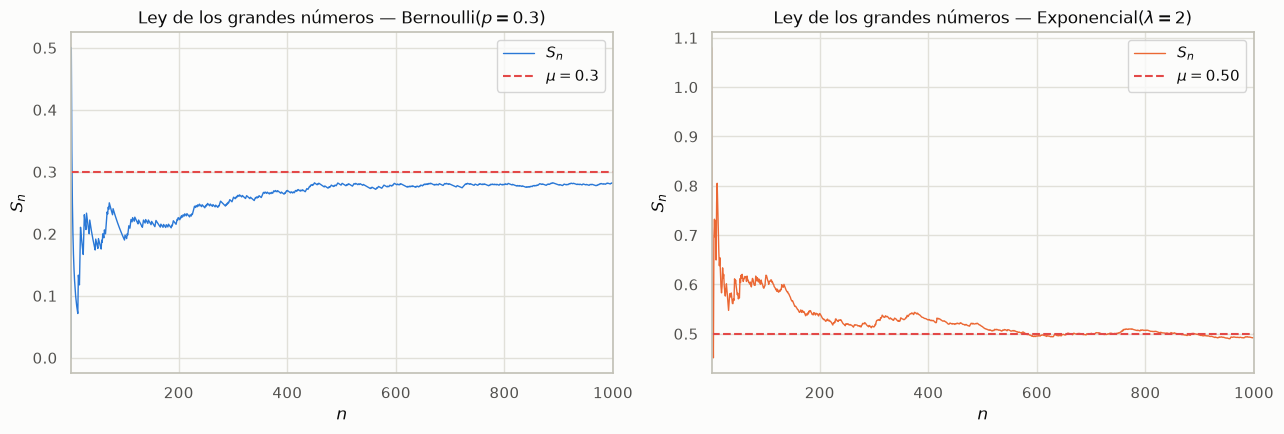

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

# Panel discreto
ax = axes[0]
ax.plot(n_arr, promedios_discretos, color=PALETTE_CATEGORICAL[0], linewidth=1.0, label=r"$S_n$")
ax.axhline(mu_discreta, color=COLOR_MEAN, linestyle="--", linewidth=1.5, label=fr"$\mu = {mu_discreta}$")
ax.set_title(rf"Ley de los grandes números — Bernoulli($p={p_bernoulli}$)")
ax.set_xlabel("$n$")
ax.set_ylabel(r"$S_n$")
ax.legend(loc="upper right")
ax.set_xlim(1, n_muestra)

# Panel continuo
ax = axes[1]
ax.plot(n_arr, promedios_continuos, color=PALETTE_CATEGORICAL[1], linewidth=1.0, label=r"$S_n$")
ax.axhline(mu_continua, color=COLOR_MEAN, linestyle="--", linewidth=1.5, label=fr"$\mu = {mu_continua:.2f}$")
ax.set_title(rf"Ley de los grandes números — Exponencial($\lambda={lambda_exp:.0f}$)")
ax.set_xlabel("$n$")
ax.set_ylabel(r"$S_n$")
ax.legend(loc="upper right")
ax.set_xlim(1, n_muestra)

plt.tight_layout()
plt.show()

In [27]:
# Valores finales de los promedios y diferencia absoluta con la media
print(f"Discreta  — S_1000 = {promedios_discretos[-1]:.4f}  | mu = {mu_discreta}    | |S_1000 - mu| = {abs(promedios_discretos[-1] - mu_discreta):.4f}")
print(f"Continua  — S_1000 = {promedios_continuos[-1]:.4f}  | mu = {mu_continua:.2f}  | |S_1000 - mu| = {abs(promedios_continuos[-1] - mu_continua):.4f}")

Discreta  — S_1000 = 0.2820  | mu = 0.3    | |S_1000 - mu| = 0.0180
Continua  — S_1000 = 0.4923  | mu = 0.50  | |S_1000 - mu| = 0.0077


**Conclusión 3.6.** En ambos casos (Bernoulli y Exponencial) los promedios parciales $S_n$ oscilan al inicio pero se acercan visiblemente a la media teórica $\mu$ conforme $n$ crece. Este comportamiento empírico es una ilustración directa de la **Ley Débil de los Grandes Números**:

$$
\lim_{n \to \infty} P\left( |S_n - \mu| > \varepsilon \right) = 0, \quad \forall \varepsilon > 0.
$$

es decir, $S_n \to \mu$ en probabilidad. Con la semilla `20260929` se obtienen, en este experimento:

- $S_{1000} \approx 0.282$ vs. $\mu = 0.3$ (Bernoulli)
- $S_{1000} \approx 0.492$ vs. $\mu = 0.5$ (Exponencial)

[Volver al índice](#indice)

<a id="conclusiones"></a>
## 10. Conclusiones

Los seis ejercicios se resolvieron combinando cálculo simbólico (`sympy`) para esperanza/varianza definidas como sumas e integrales, y cálculo numérico (`scipy.stats`, `numpy`) para los cuantiles de la normal y la simulación Monte Carlo.

Resultados clave:

1. **Poisson**: $E[Y(Y-1)] = \mu^2$, $E[Y^2] = \mu + \mu^2$, $\text{Var}(Y) = \mu$. La identidad $Y^2 = Y(Y-1) + Y$ reduce el trabajo.
2. **PMF geométrica desplazada**: $c = 1$; $P(X > 4) = 1/16$, $P(6 \le X \le 8) = 7/256$.
3. **Beta**: uniforme cuando $\alpha = \beta = 1$; $E(Y) = \alpha/(\alpha + \beta)$, $\text{Var}(Y) = \alpha\beta/((\alpha + \beta)^2(\alpha + \beta + 1))$.
4. **Normal** $\mathcal{N}(5, 16)$: $P[X > 4] = 0.5987$, $P[2 \le X \le 7] = 0.4648$, $a = b \approx 9.841$, $c \approx 13.083$.
5. **Marginales**: $c = 1$, $f_X(x) = f_Y(y) = x + 1/2$, $E[Y] = 7/12$.
6. **LLN**: la simulación con 1000 muestras de Bernoulli$(0.3)$ y Exponencial$(2)$ muestra la convergencia $S_n \to \mu$ en probabilidad.

[Volver al índice](#indice)